# Mobility-Guided EGNN Fold 1

Notebook de análisis para el pipeline jerárquico:
ESM cacheado -> XGBoost mobility prior -> EGNN guiado por movilidad.

El notebook carga artefactos existentes y, si faltan, puede regenerarlos ejecutando el script dedicado.

In [103]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

def _detect_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'scripts' / 'run_mobility_guided_fold1.py').is_file():
            return candidate
        nested = candidate / 'TPF_Vision_Avanzada'
        if (nested / 'scripts' / 'run_mobility_guided_fold1.py').is_file():
            return nested
    raise FileNotFoundError('Could not locate project root containing scripts/run_mobility_guided_fold1.py')

PROJECT_ROOT = _detect_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

REPORT_ROOT = PROJECT_ROOT / 'reports' / 'fold1' / 'mobility_guided_egnn'
MOBILITY_REPORT_ROOT = PROJECT_ROOT / 'reports' / 'fold1' / 'mobility_prior'
FIGURE_ROOT = PROJECT_ROOT / 'figures' / 'mobility_guided_egnn'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'mobility_guided_egnn'
SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'run_mobility_guided_fold1.py'

FORCE_RERUN = False
RUN_PIPELINE_IF_NEEDED = False
PIPELINE_ARGS = [
    '--fold-id', '1',
    '--batch-size', '1',
    '--num-workers', '2',
    '--max-epochs', '15',
    '--patience', '4',
    '--learning-rate', '1e-4',
    '--grad-clip', '1.0',
    '--distance-lambdas', '0.0', '0.1', '0.5', '1.0',
    '--weighted-alpha', '1.0',
    '--mobility-threshold', '2.0',
]

print('PROJECT_ROOT =', PROJECT_ROOT)
print('REPORT_ROOT =', REPORT_ROOT)
print('FIGURE_ROOT =', FIGURE_ROOT)
print('CHECKPOINT_ROOT =', CHECKPOINT_ROOT)
print('embeddings_loaded_from_cache = True')


PROJECT_ROOT = /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada
REPORT_ROOT = /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/reports/fold1/mobility_guided_egnn
FIGURE_ROOT = /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/figures/mobility_guided_egnn
CHECKPOINT_ROOT = /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/checkpoints/mobility_guided_egnn
embeddings_loaded_from_cache = True


In [104]:
summary_path = REPORT_ROOT / 'summary.json'
if FORCE_RERUN or (RUN_PIPELINE_IF_NEEDED and not summary_path.is_file()):
    print('Automatic rerun is disabled in this notebook. Run scripts/run_mobility_guided_fold1.py directly if you need to regenerate artifacts.')
else:
    print('Using existing mobility-guided Fold 1 artifacts when available.')

PIPELINE_READY = summary_path.is_file() and (REPORT_ROOT / 'ablation_comparison.csv').is_file() and (MOBILITY_REPORT_ROOT / 'mobility_prior_summary.json').is_file()
print('PIPELINE_READY =', PIPELINE_READY)
if not PIPELINE_READY:
    print('Expected artifacts are missing. The analysis cells below will only display available files.')

Using existing mobility-guided Fold 1 artifacts when available.
PIPELINE_READY = True


In [105]:
if PIPELINE_READY:
    with summary_path.open('r', encoding='utf-8') as handle:
        summary = json.load(handle)

    comparison_table = pd.read_csv(REPORT_ROOT / 'ablation_comparison.csv')
    mobility_prior_summary = json.loads((MOBILITY_REPORT_ROOT / 'mobility_prior_summary.json').read_text(encoding='utf-8'))
    train_predictions = pd.read_csv(MOBILITY_REPORT_ROOT / 'predictions' / 'train_p_change.csv')
    val_predictions = pd.read_csv(MOBILITY_REPORT_ROOT / 'predictions' / 'validation_p_change.csv')
    test_predictions = pd.read_csv(MOBILITY_REPORT_ROOT / 'predictions' / 'test_p_change.csv')

    print('Mobility prior loaded from cache:', mobility_prior_summary['embeddings_loaded_from_cache'])
    display(pd.DataFrame([summary['identity']]))
    display(comparison_table)
    display(pd.DataFrame([{
        'train_size': mobility_prior_summary['train_size'],
        'validation_size': mobility_prior_summary['validation_size'],
        'test_size': mobility_prior_summary['test_size'],
        'classifier_test_roc_auc': mobility_prior_summary['classifier_metrics']['test']['roc_auc'],
        'regressor_test_rmse': mobility_prior_summary['regressor_metrics']['test']['rmse'],
    }]))
else:
    summary = {}
    comparison_table = pd.DataFrame(columns=['Method', 'RMSD Pred→Target', 'RMSD Source→Target', 'RMSD Source→Pred', 'Improvement', 'Success Rate', 'Mean True Motion', 'Mean Pred Motion'])
    mobility_prior_summary = {'embeddings_loaded_from_cache': True, 'train_size': 0, 'validation_size': 0, 'test_size': 0, 'classifier_metrics': {'test': {'roc_auc': float('nan')}}, 'regressor_metrics': {'test': {'rmse': float('nan')}}}
    train_predictions = pd.DataFrame()
    val_predictions = pd.DataFrame()
    test_predictions = pd.DataFrame()
    print('Artifacts unavailable; skipping metric tables.')


Mobility prior loaded from cache: True


,Method,RMSD Pred→Target,RMSD Source→Target,RMSD Source→Pred,Improvement,Success Rate,Mean True Motion,Mean Pred Motion
0,Identity,3.316142,3.316142,0.0,0.0,0.0,2.253116,0.0


,Method,RMSD Pred→Target,RMSD Source→Target,RMSD Source→Pred,Improvement,Success Rate,Mean True Motion,Mean Pred Motion
0,Identity,3.316142,3.316142,0.000000,0.000000,0.000000,2.253116,0.000000
1,EGNN_no_prior,3.589914,3.316142,1.914622,-0.273773,0.237624,2.253116,1.684579
2,MobilityGuidedEGNN,3.741143,3.316142,2.153300,-0.425002,0.168317,2.253116,1.417964
3,MobilityGuidedEGNN_dist_0p0,3.690476,3.316142,2.156733,-0.374335,0.207921,2.253116,1.329249
4,MobilityGuidedEGNN_dist_0p1,3.554099,3.316142,1.923081,-0.237957,0.267327,2.253116,1.182642
5,MobilityGuidedEGNN_dist_0p5,3.658375,3.316142,1.954269,-0.342234,0.188119,2.253116,1.373021
6,MobilityGuidedEGNN_dist_1p0,3.912602,3.316142,2.693404,-0.596461,0.148515,2.253116,1.735637
7,MobilityGuidedEGNN_weighted,4.014170,3.316142,2.756511,-0.698029,0.128713,2.253116,2.096347


,train_size,validation_size,test_size,classifier_test_roc_auc,regressor_test_rmse
0,61179,23501,28055,0.85232,2.775453


Classifier metrics


,accuracy,precision,recall,f1,pr_auc,roc_auc
train,0.901028,0.881559,0.900109,0.890737,0.961465,0.967833
validation,0.633803,0.790857,0.546061,0.646048,0.801574,0.747917
test,0.784423,0.695258,0.640809,0.666924,0.712256,0.852320


Regressor metrics


,mae,rmse,pearson,spearman
train,0.752614,1.100858,0.962846,0.782266
validation,1.864584,2.955024,0.565902,0.496585
test,1.268605,2.775453,0.557165,0.574285


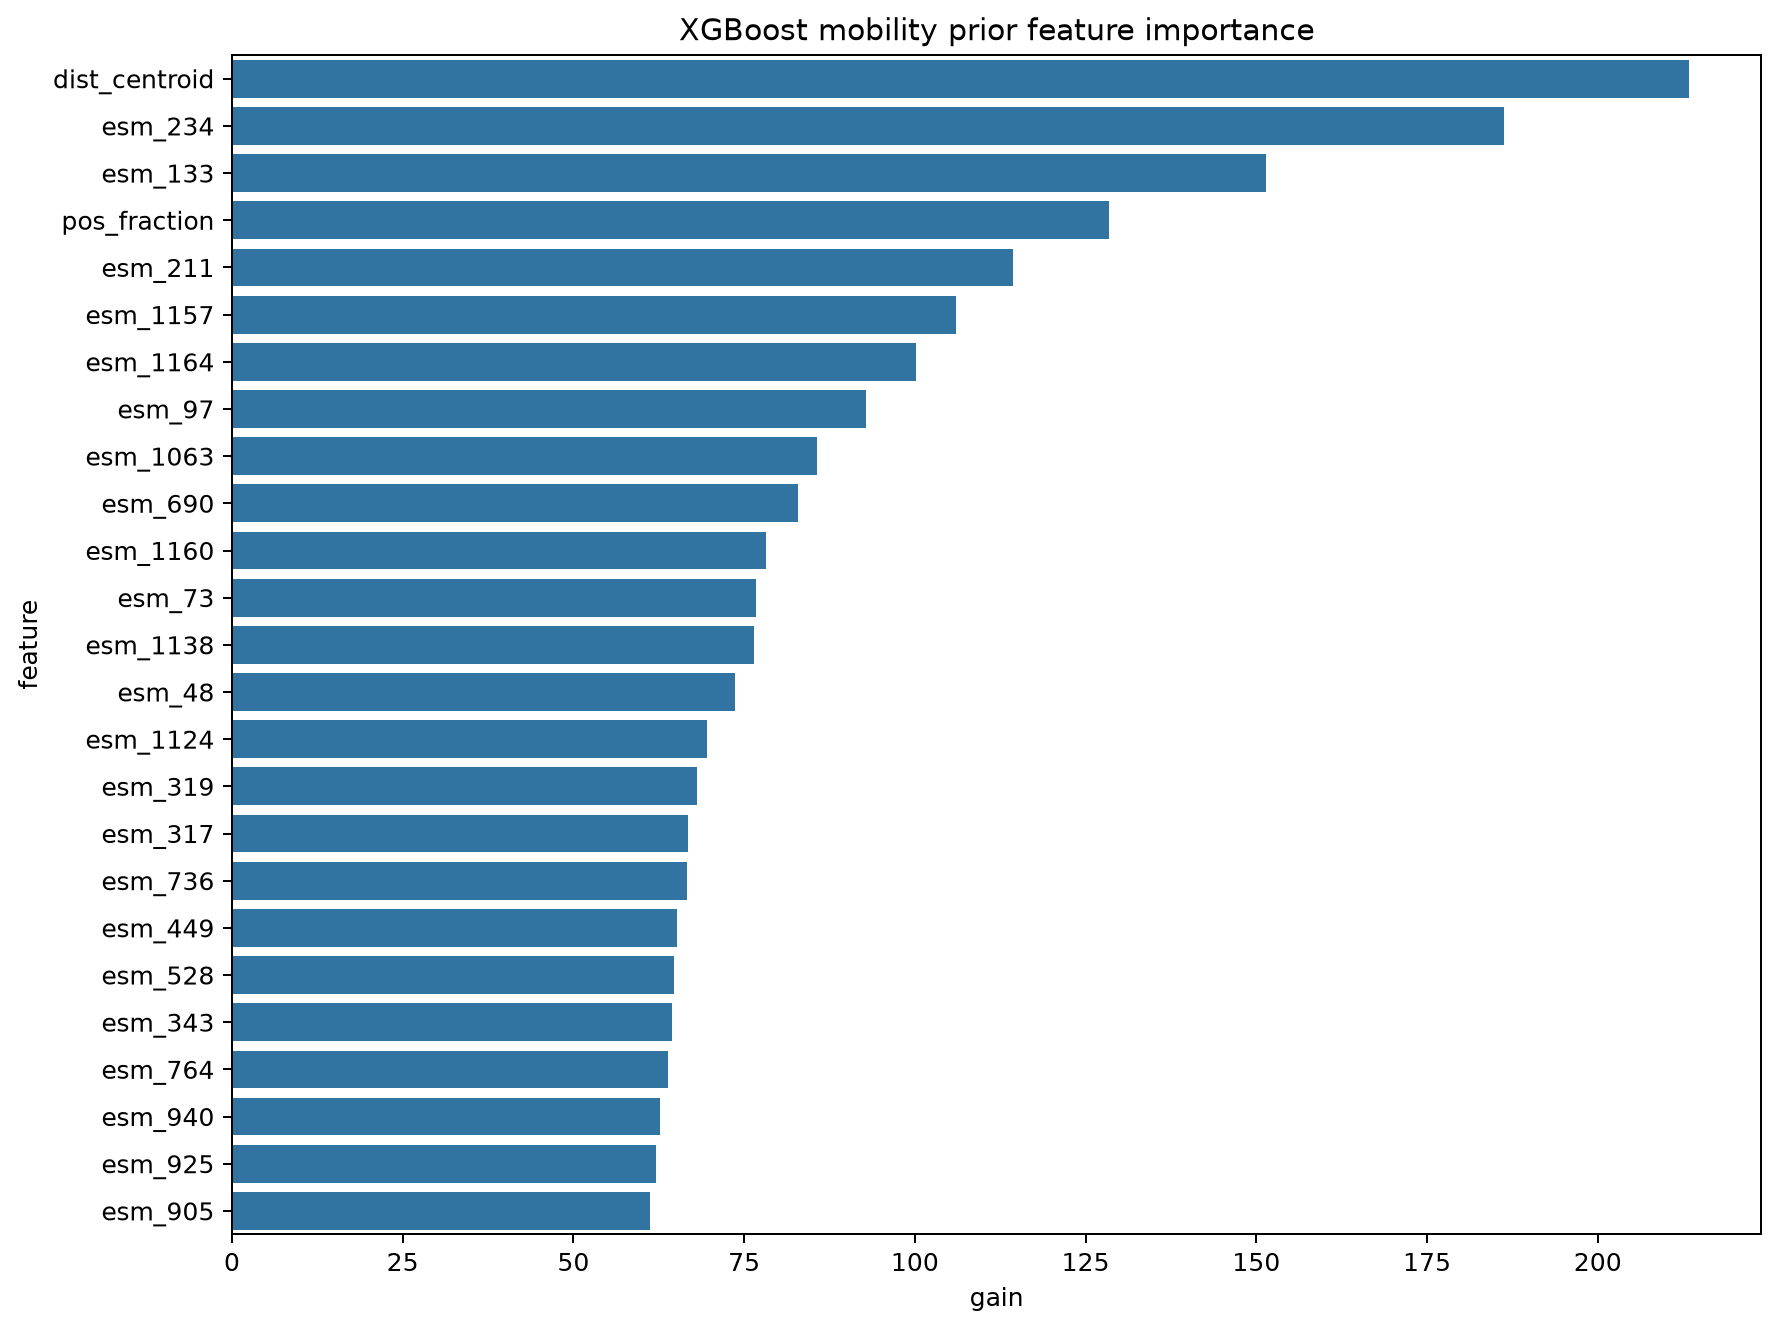

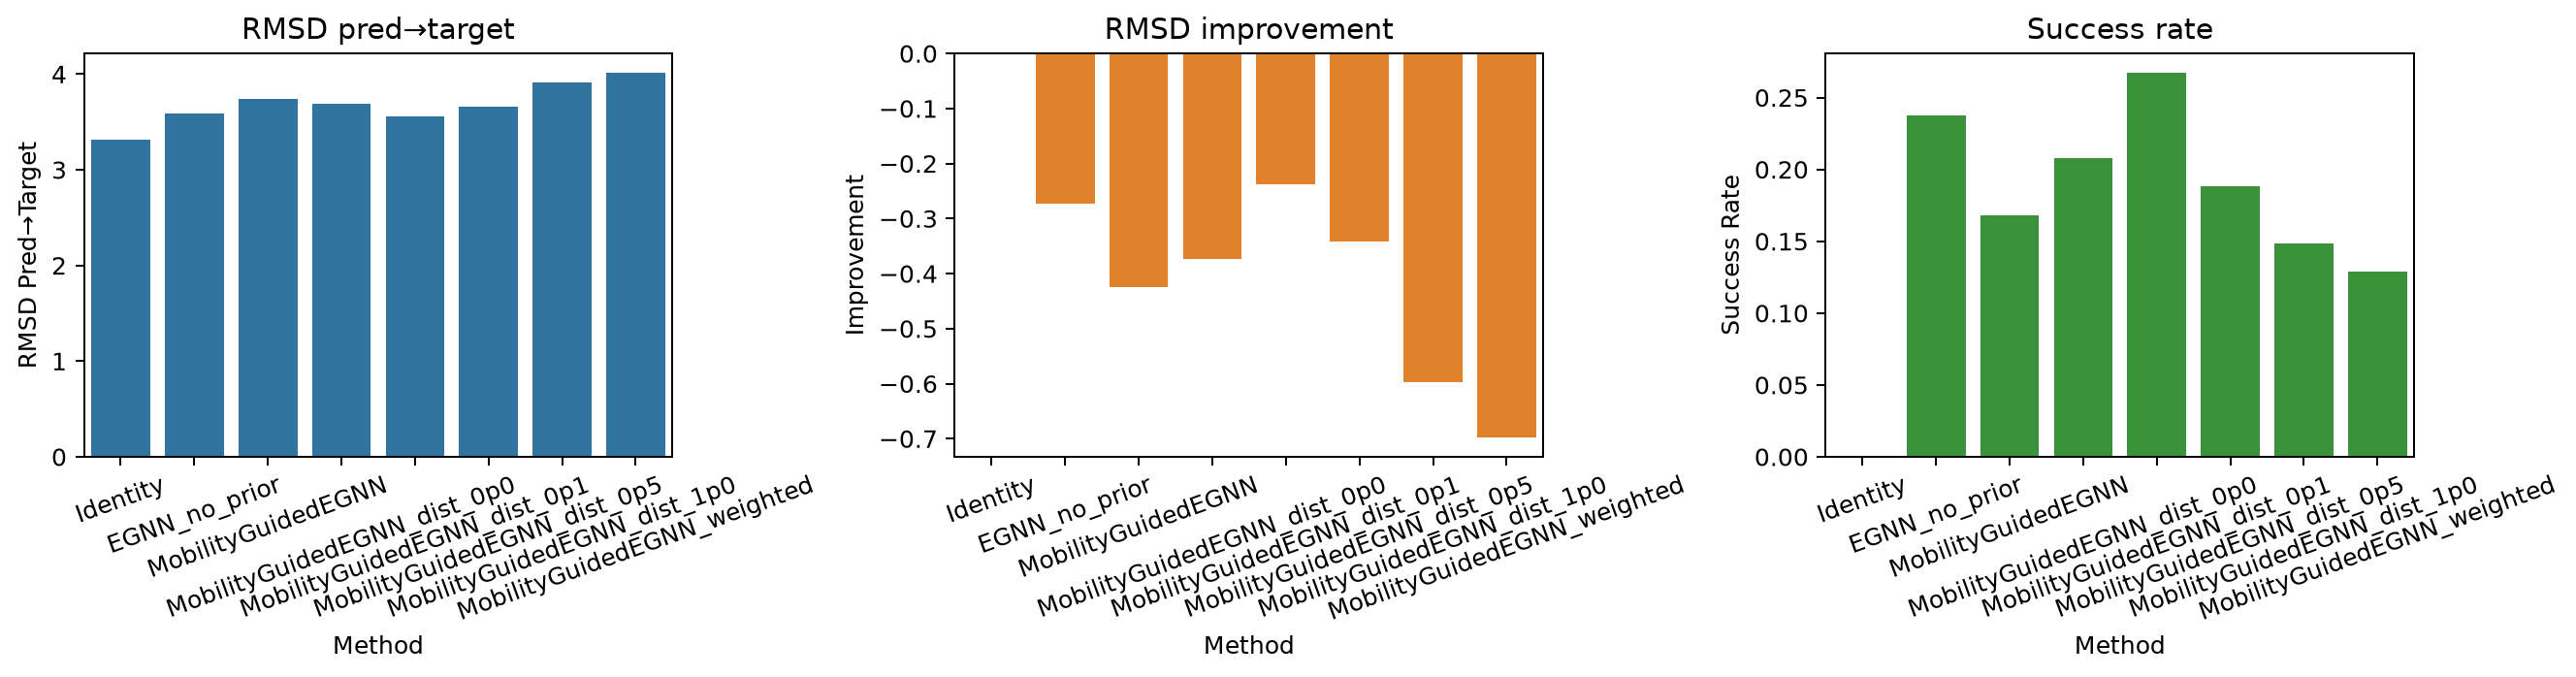

In [106]:
print('Classifier metrics')
display(pd.DataFrame(mobility_prior_summary['classifier_metrics']).T)
print('Regressor metrics')
display(pd.DataFrame(mobility_prior_summary['regressor_metrics']).T)

feature_importance = FIGURE_ROOT / 'xgb_feature_importance.png'
method_comparison = FIGURE_ROOT / 'method_comparison.png'
if feature_importance.is_file():
    display(Image(filename=str(feature_importance)))
if method_comparison.is_file():
    display(Image(filename=str(method_comparison)))


EGNN_no_prior_training_curves.png


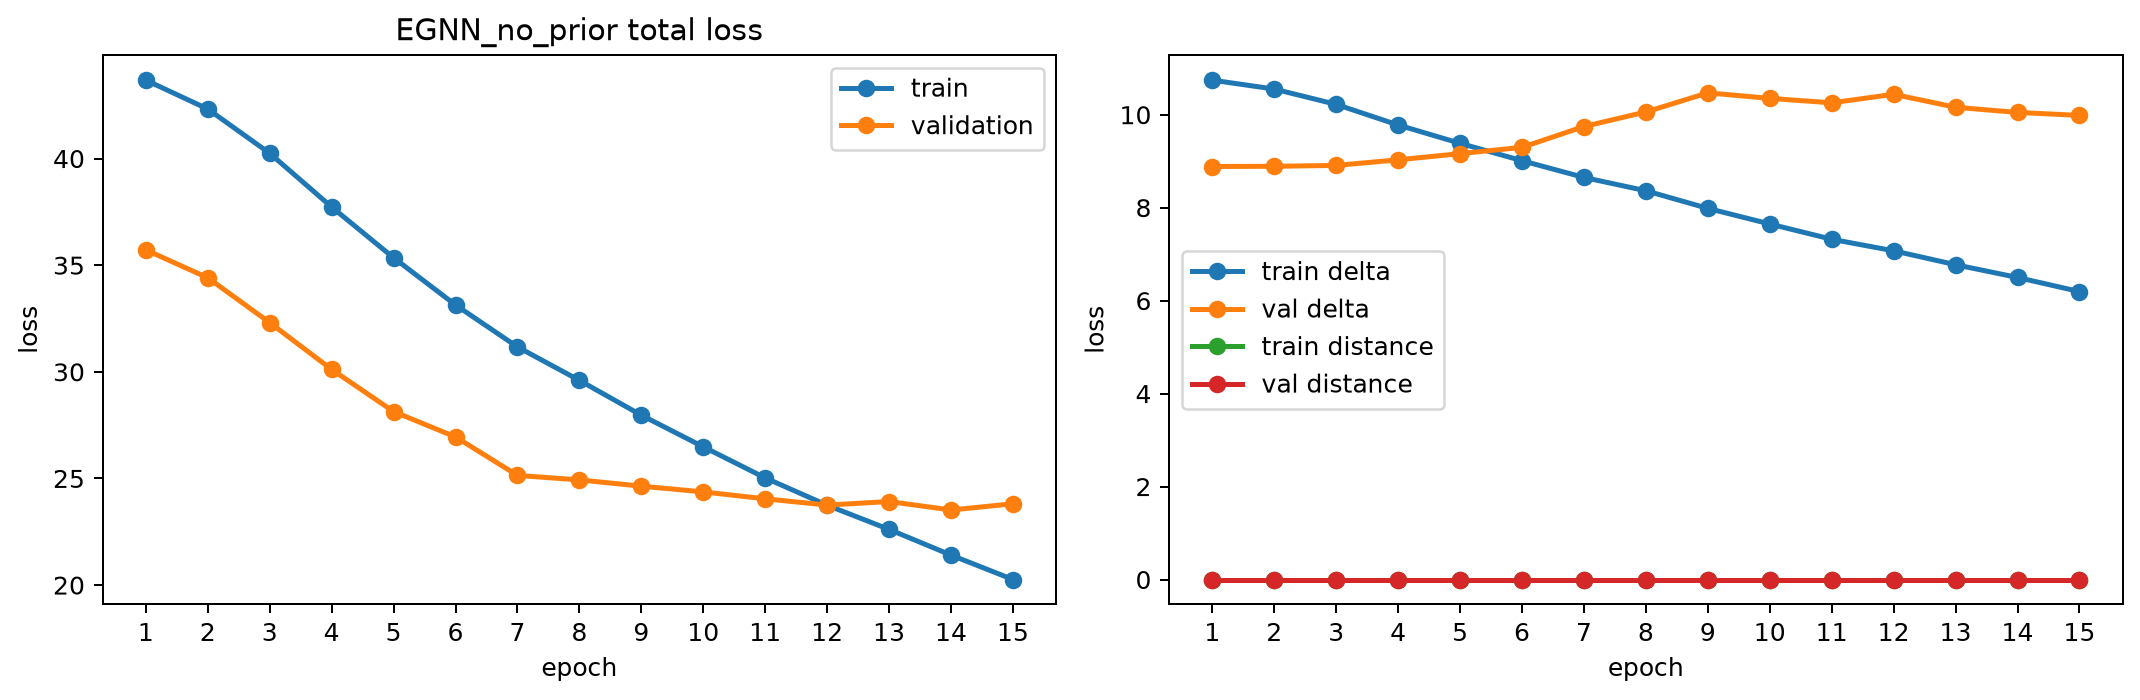

MobilityGuidedEGNN_dist_0p0_training_curves.png


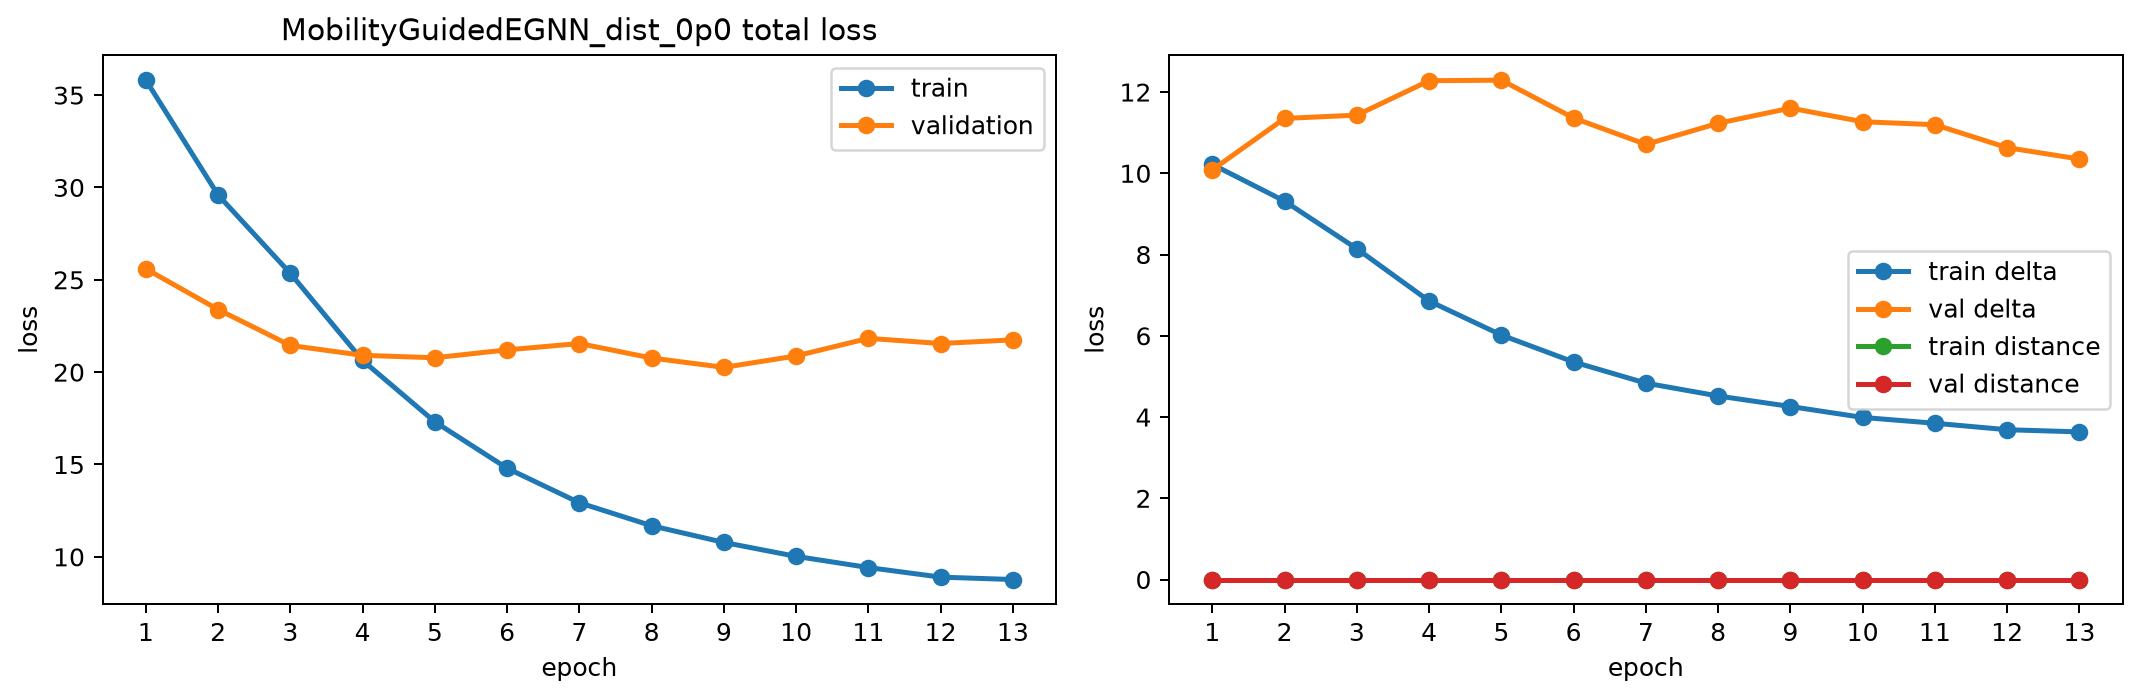

MobilityGuidedEGNN_dist_0p1_training_curves.png


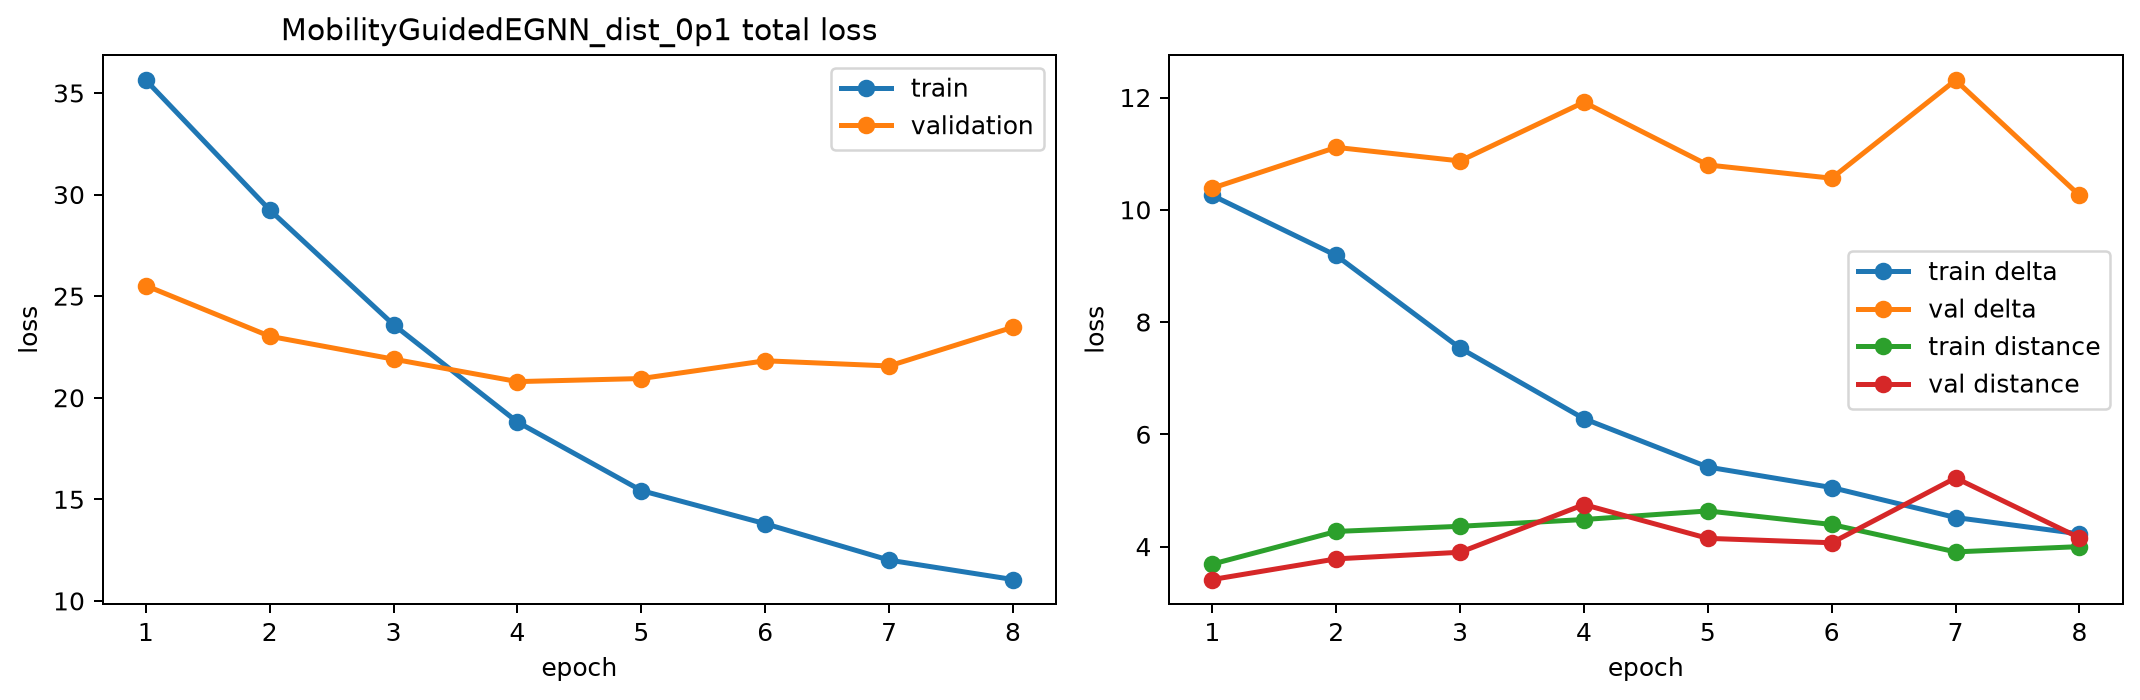

MobilityGuidedEGNN_dist_0p5_training_curves.png


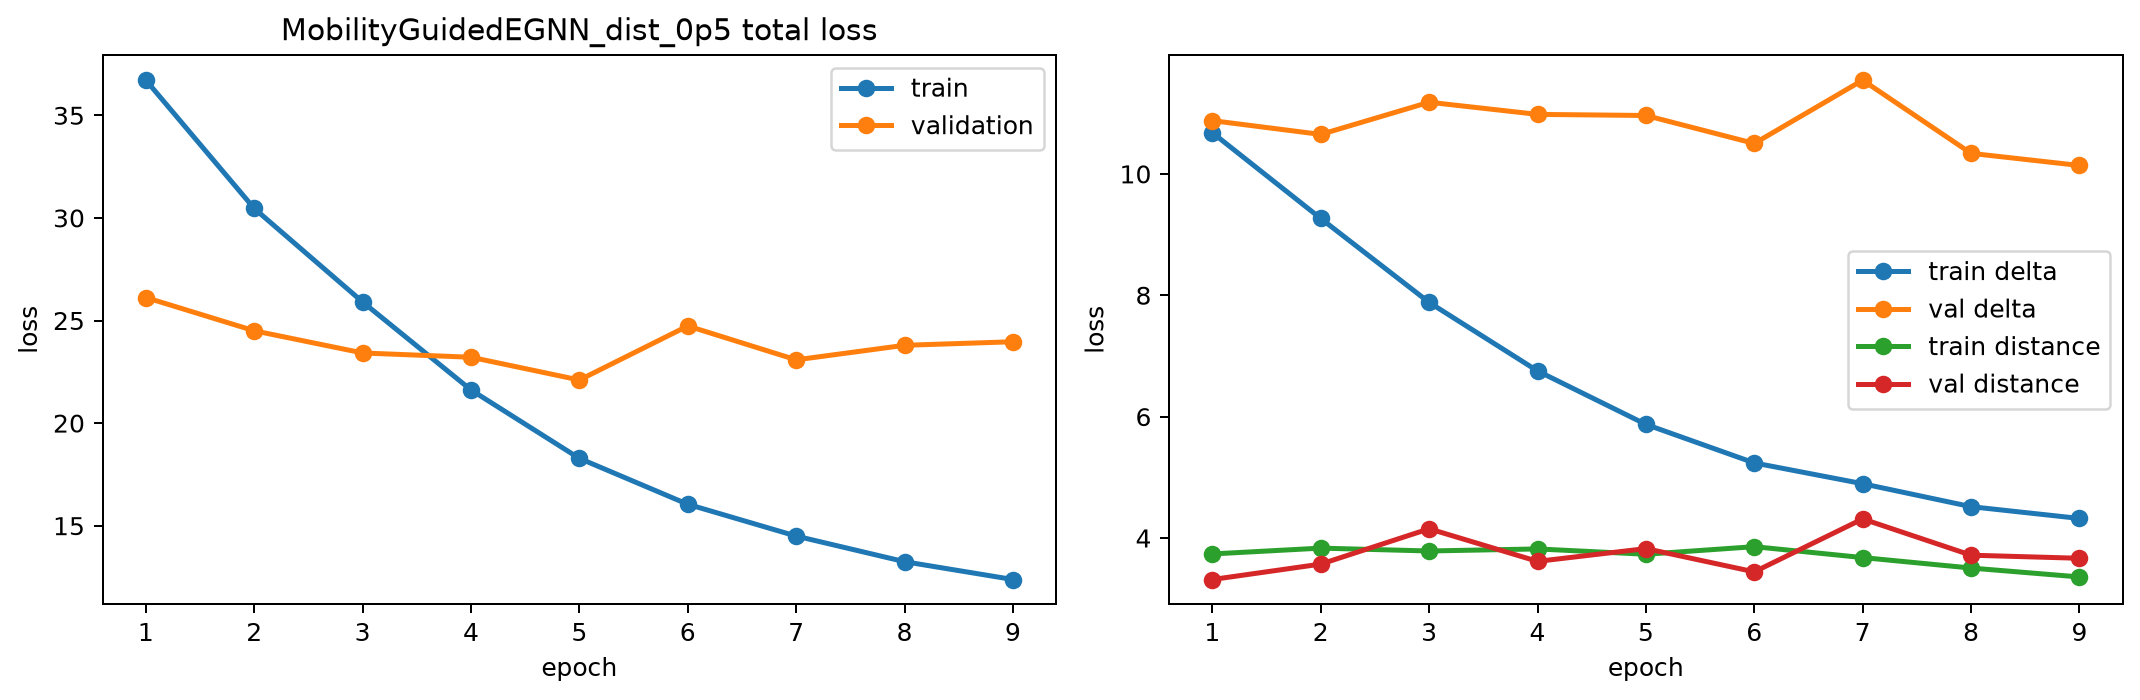

MobilityGuidedEGNN_dist_1p0_training_curves.png


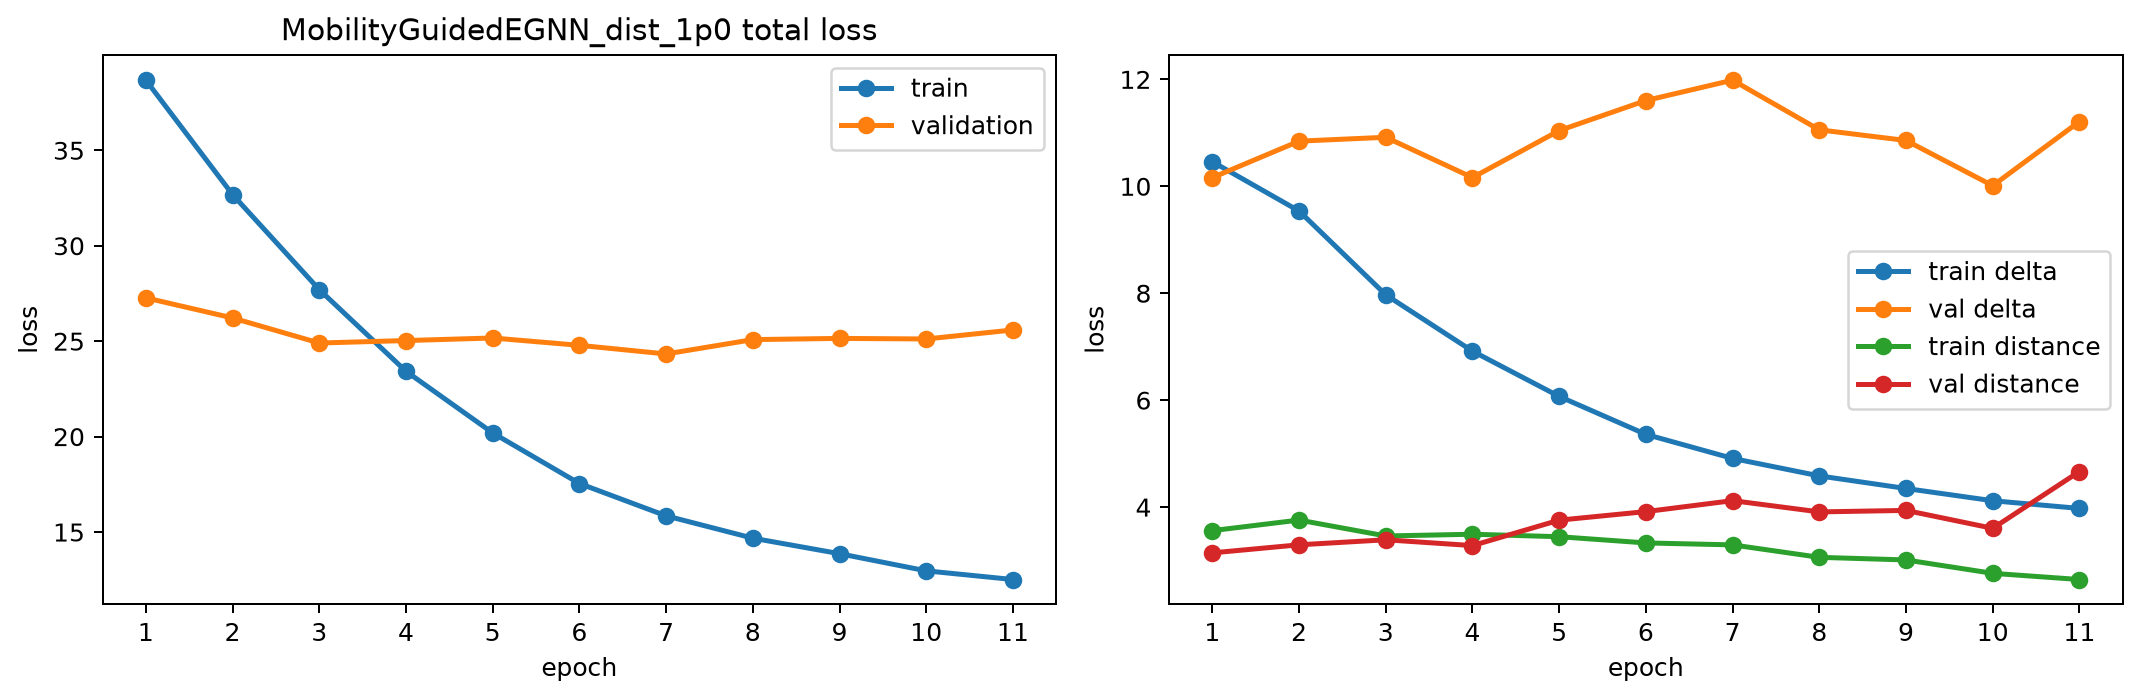

MobilityGuidedEGNN_training_curves.png


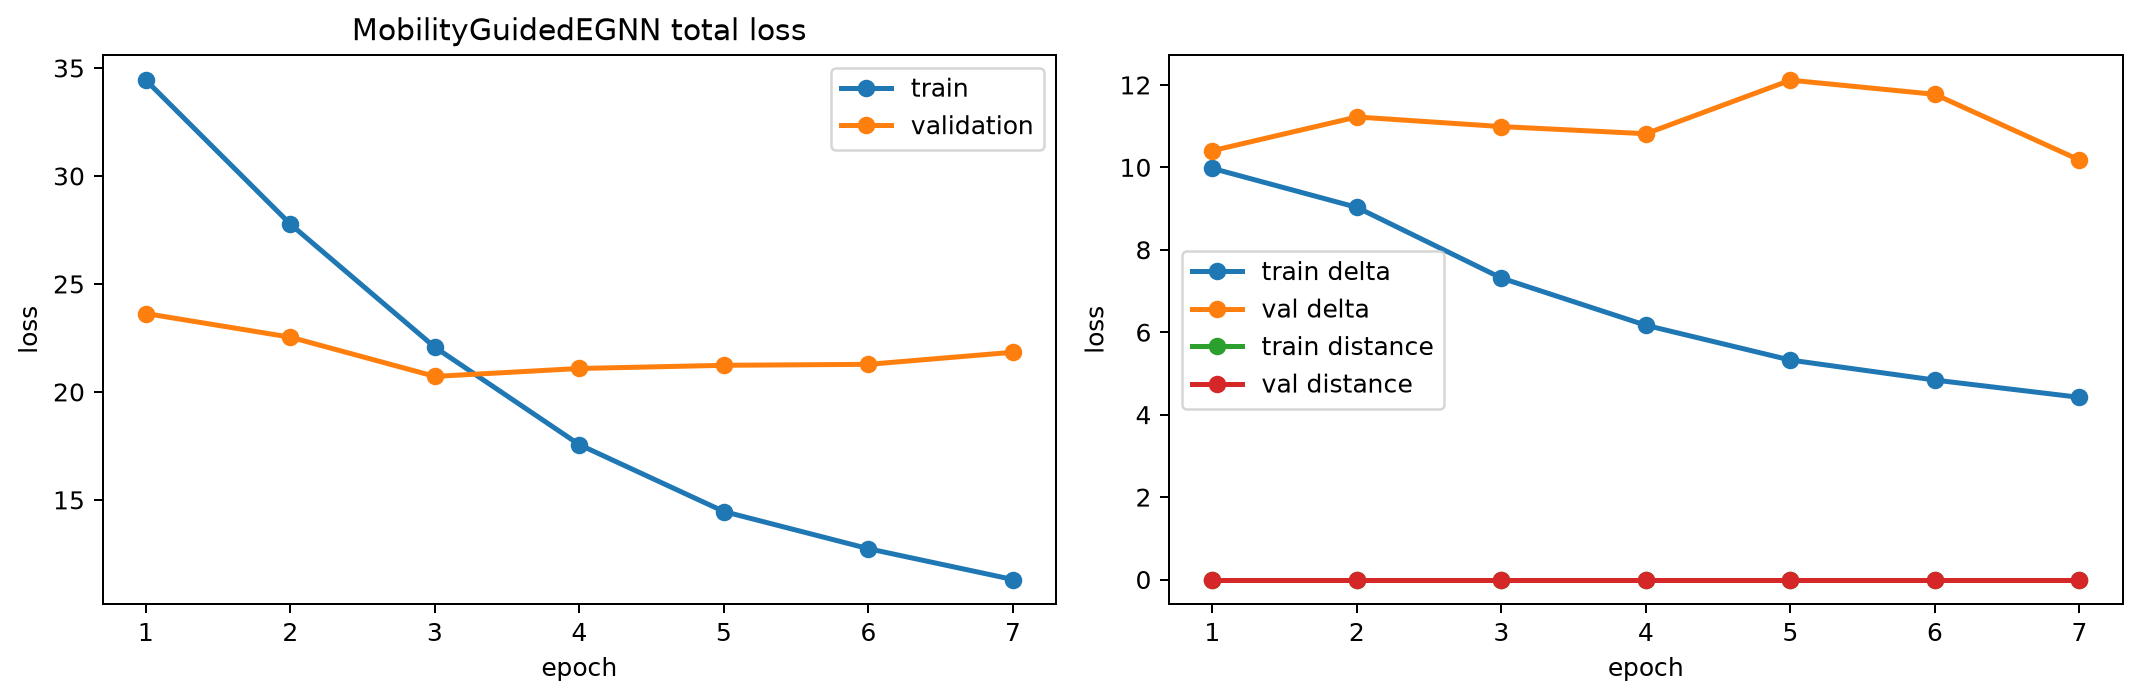

best_overlay.png


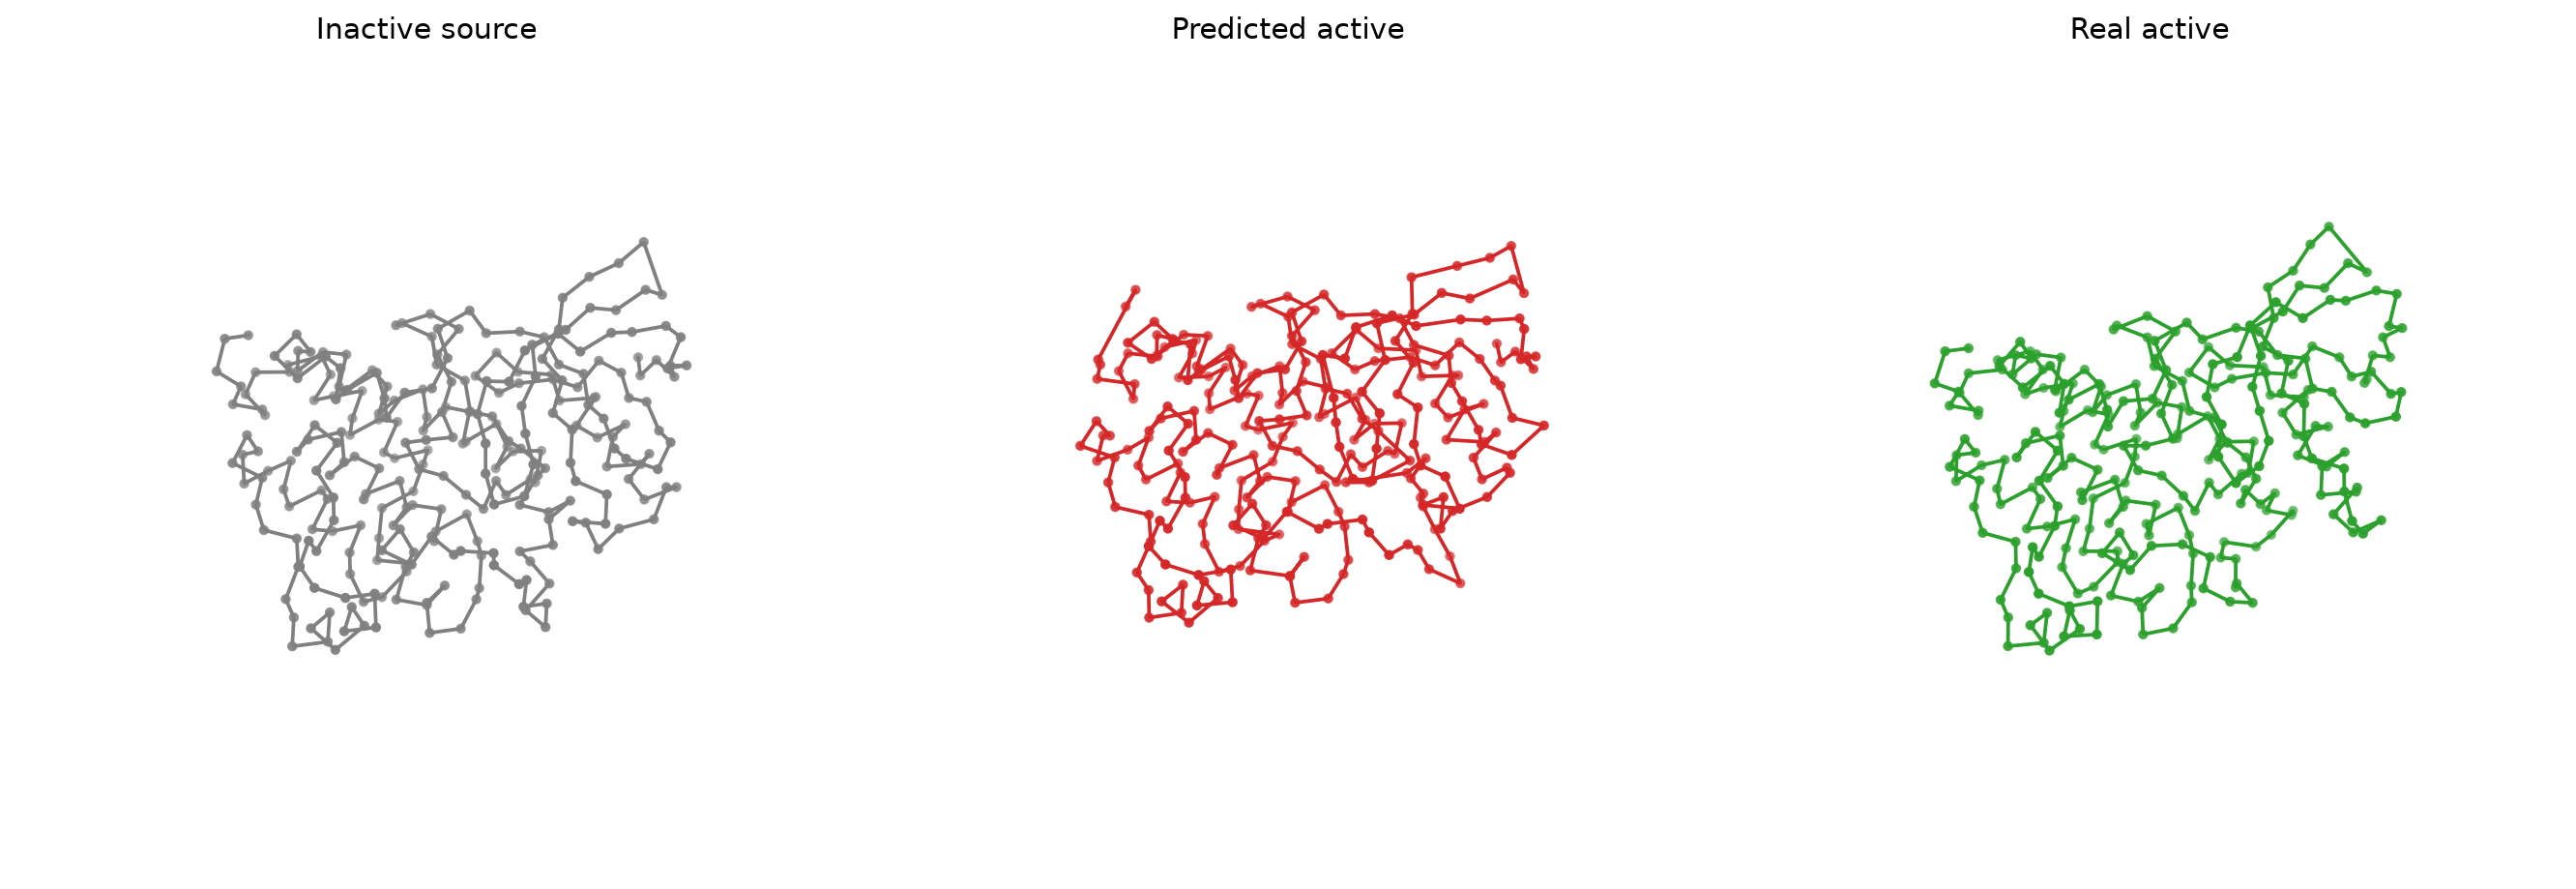

best_motion_overlay.png


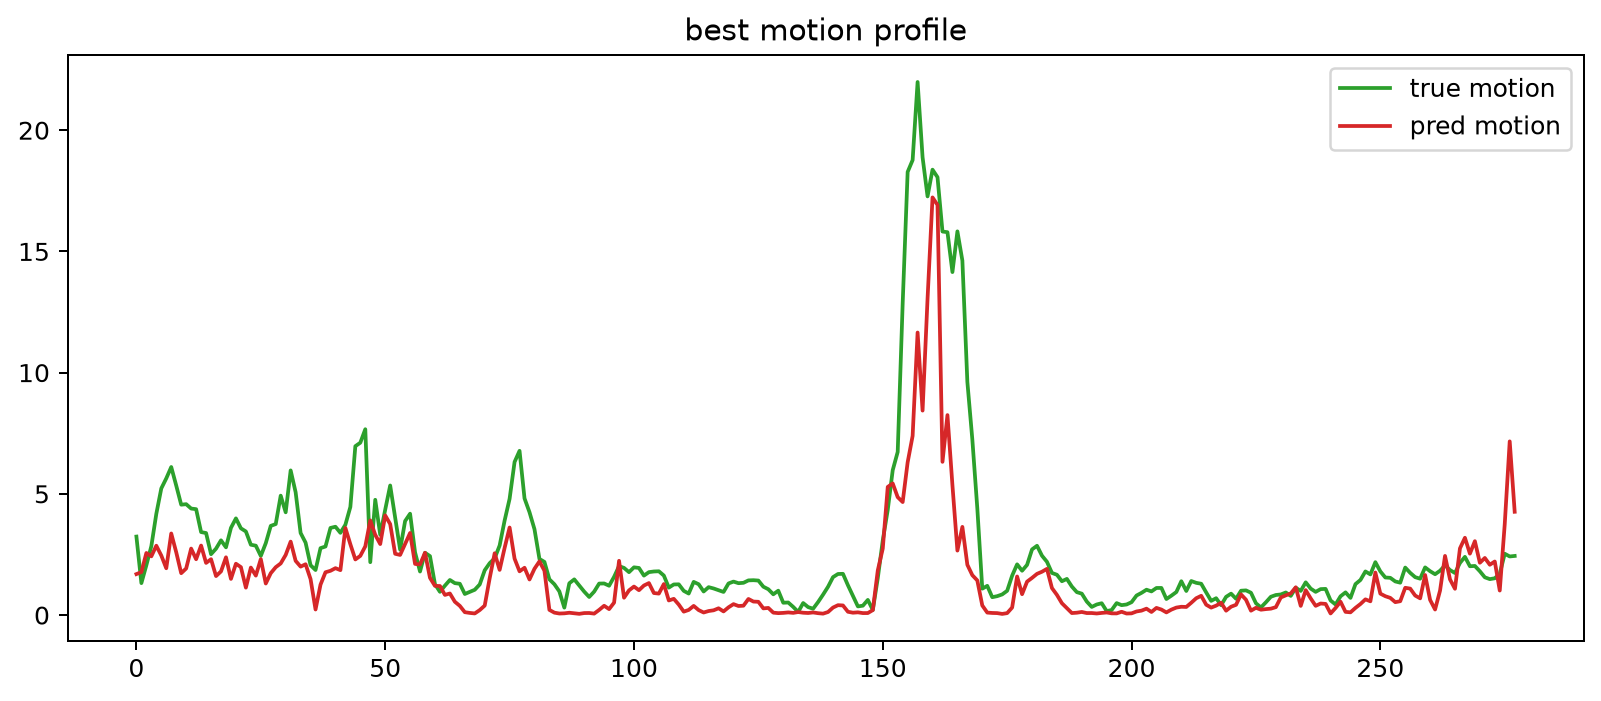

best_residue_error.png


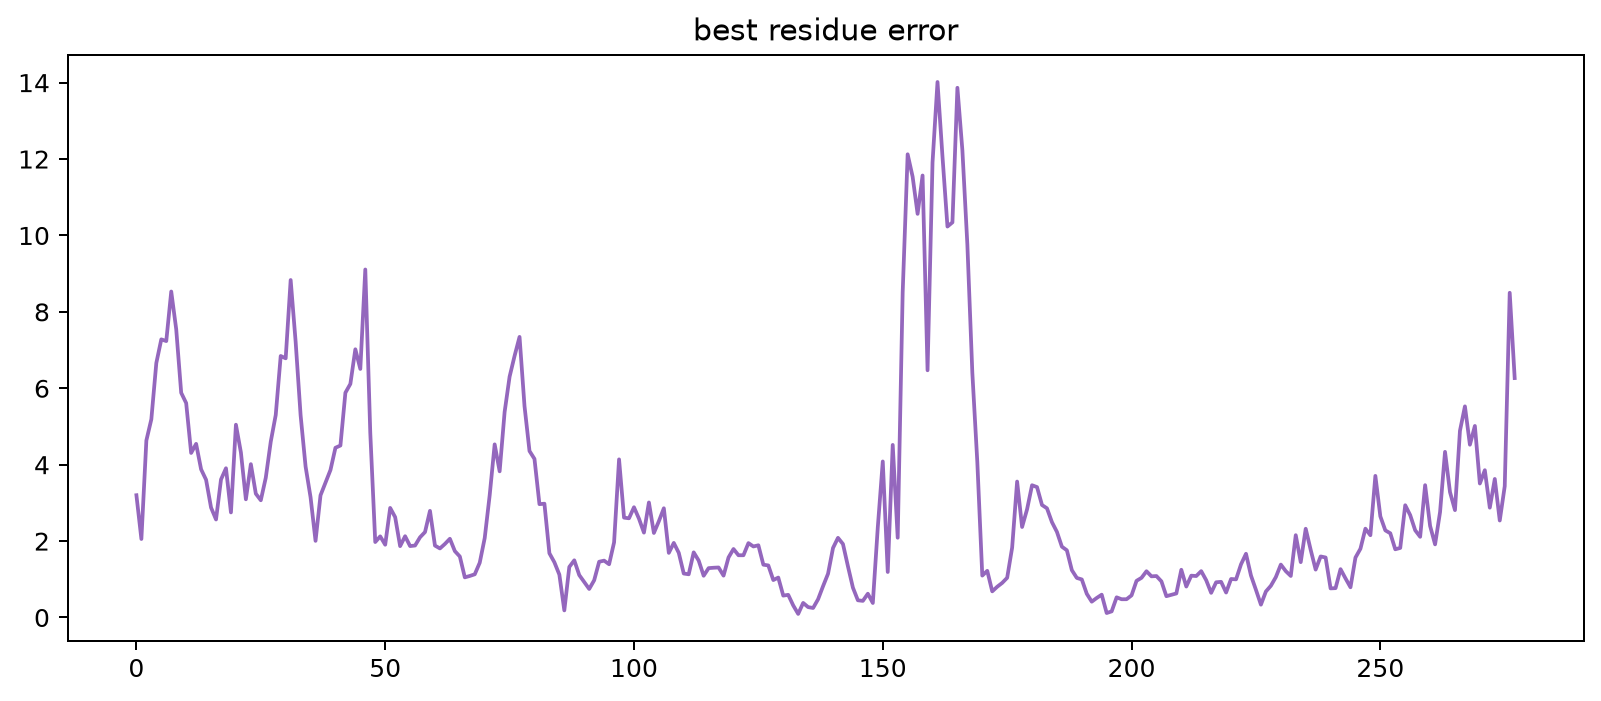

median_overlay.png


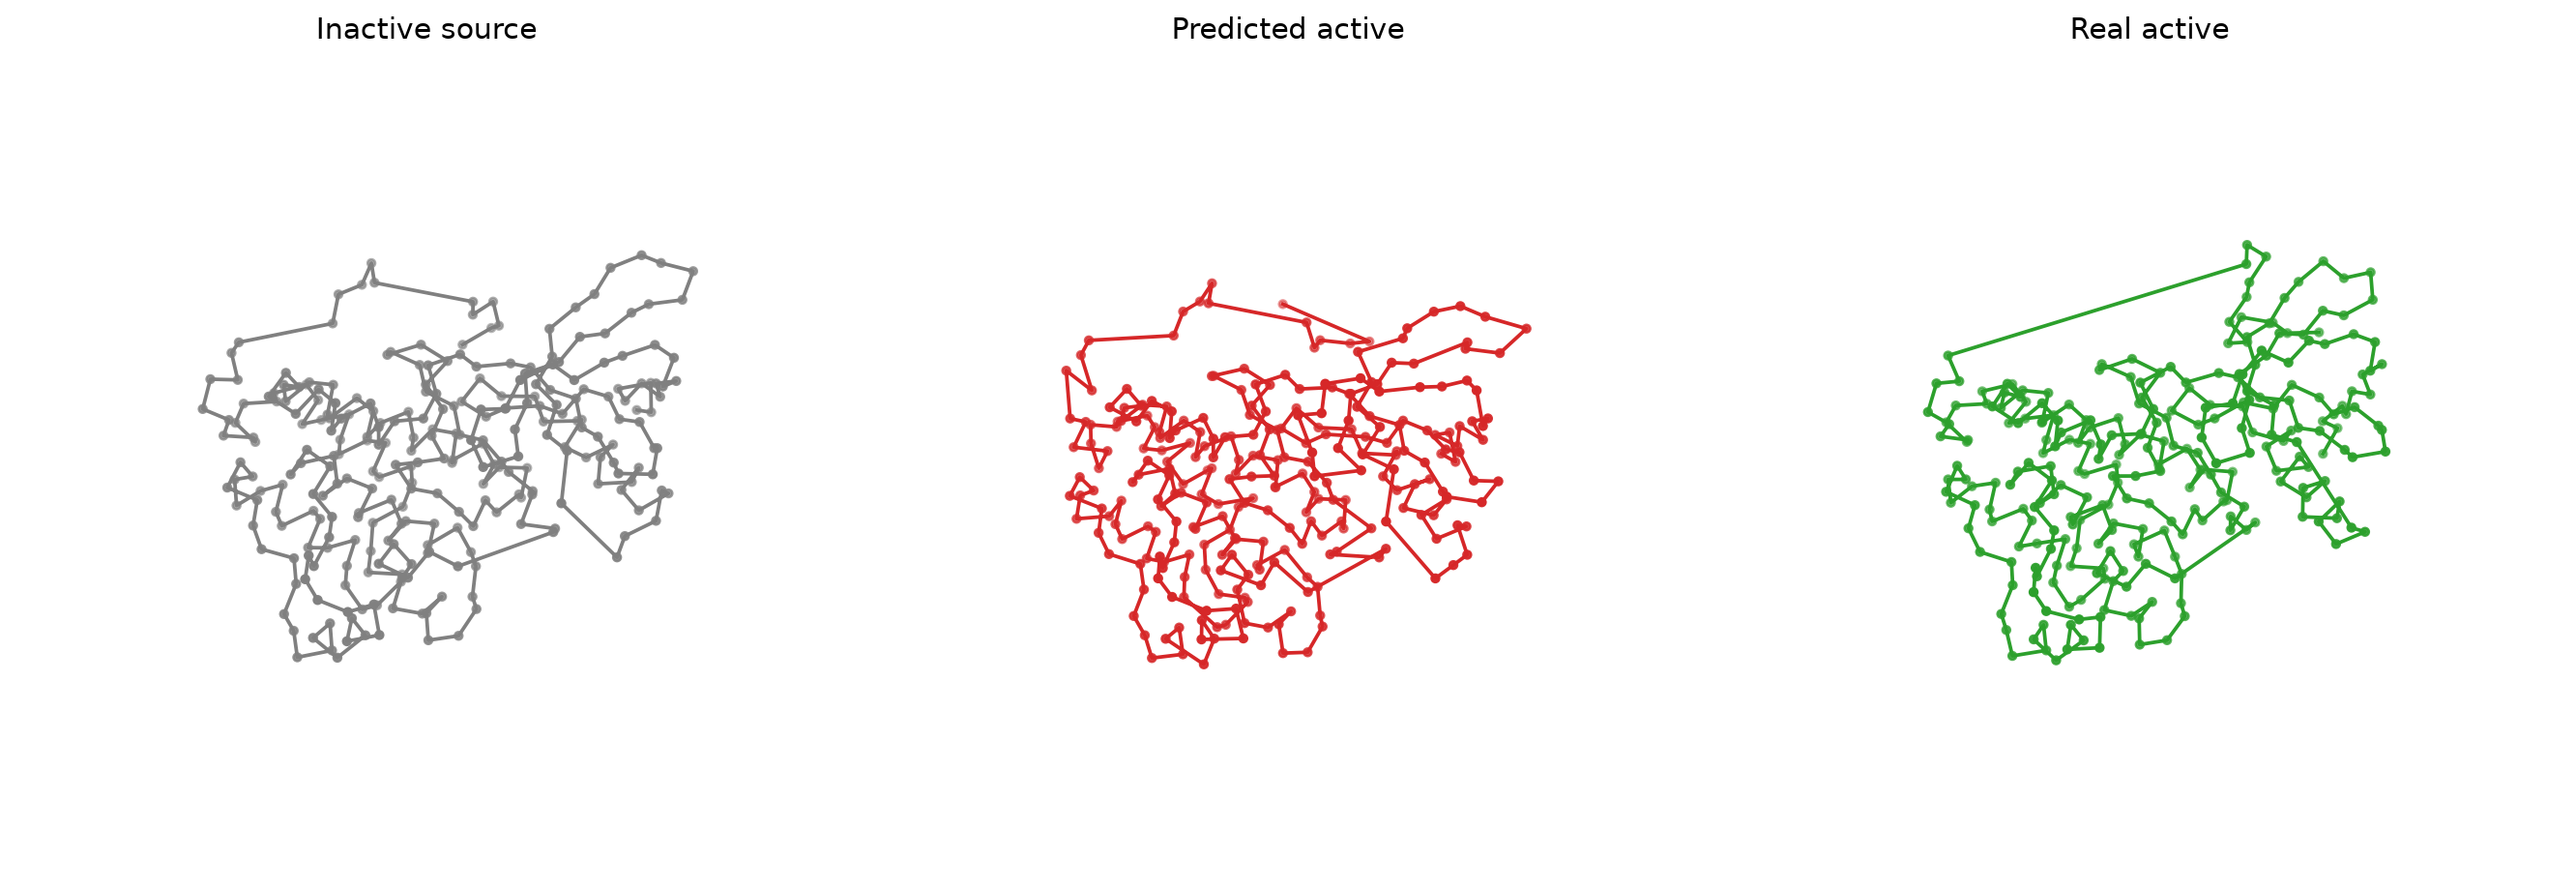

median_motion_overlay.png


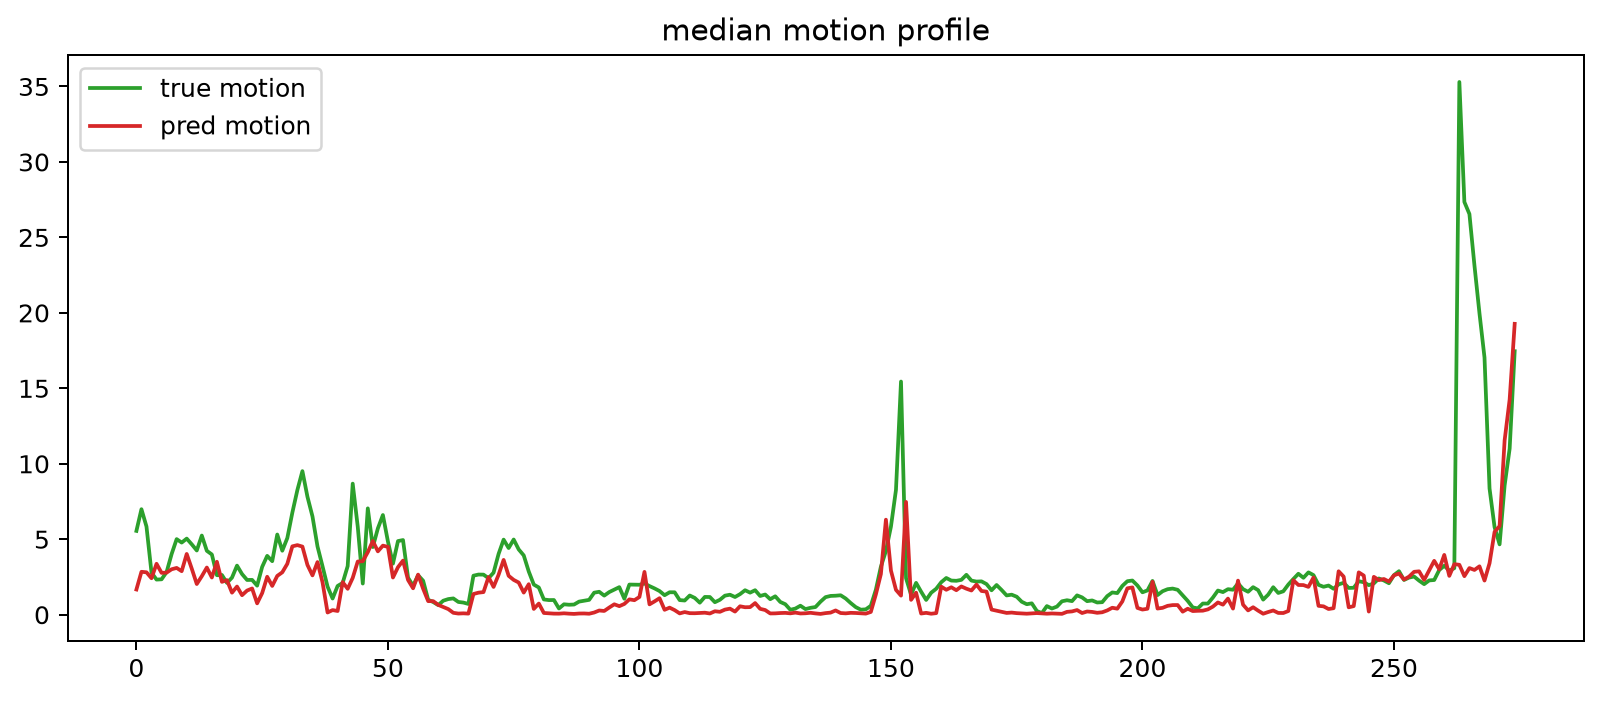

median_residue_error.png


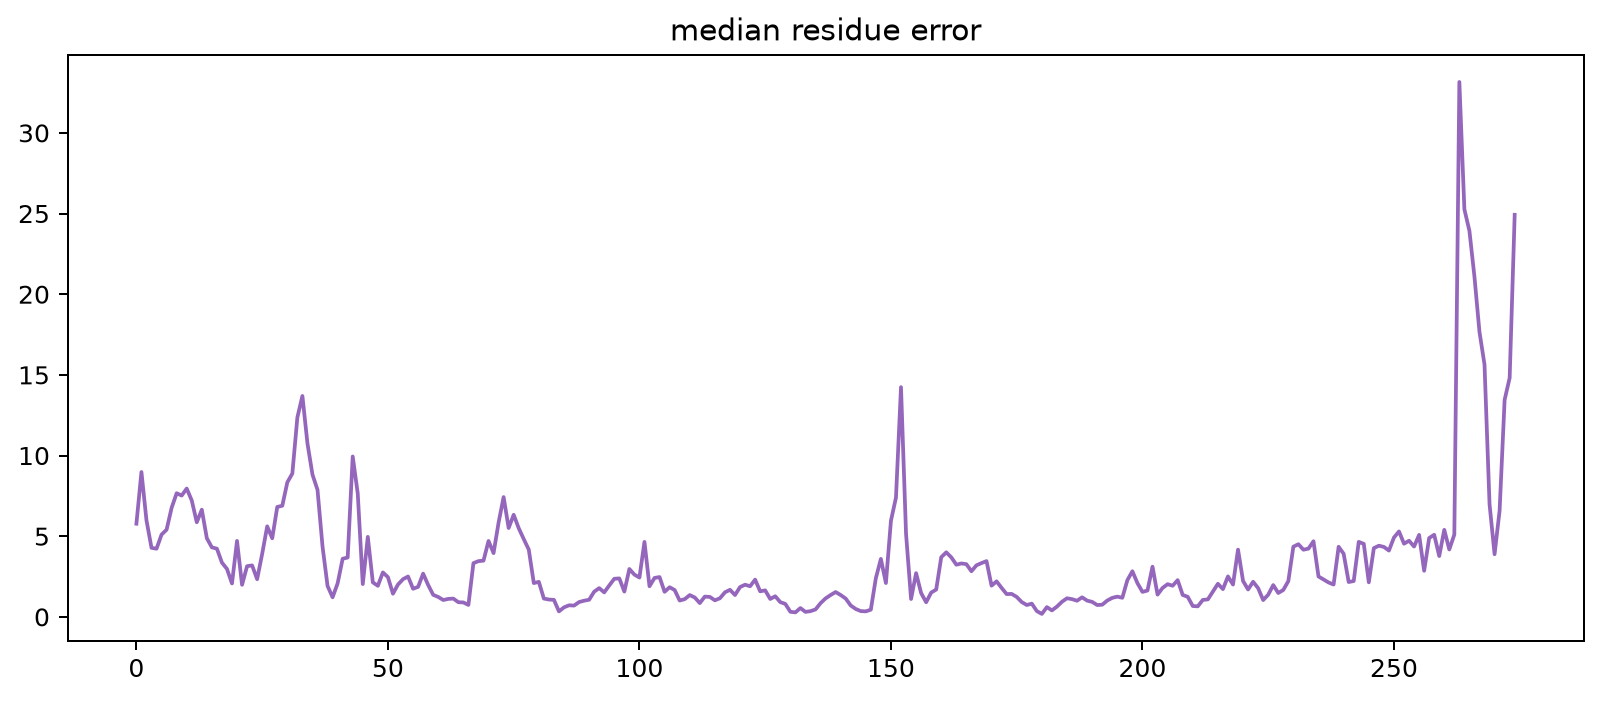

worst_overlay.png


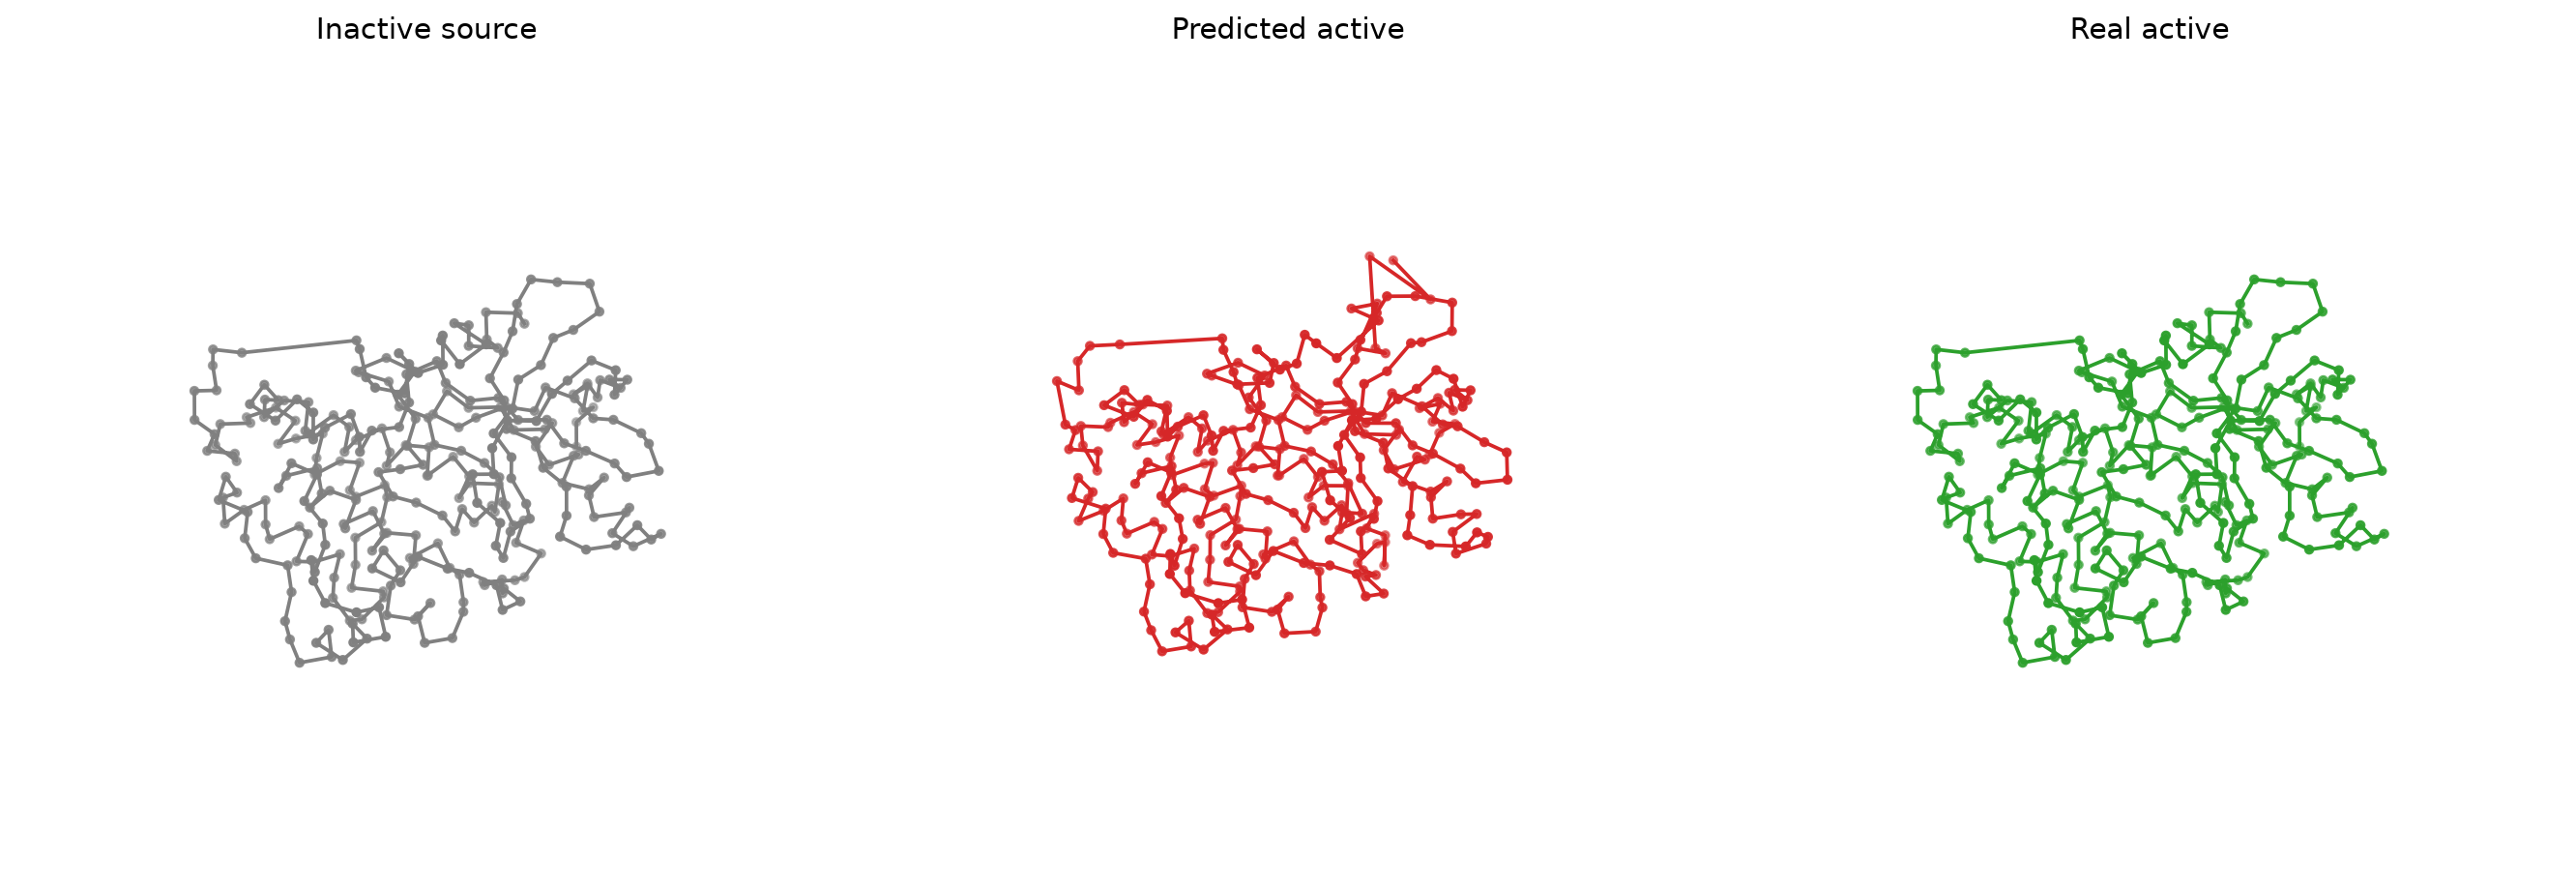

worst_motion_overlay.png


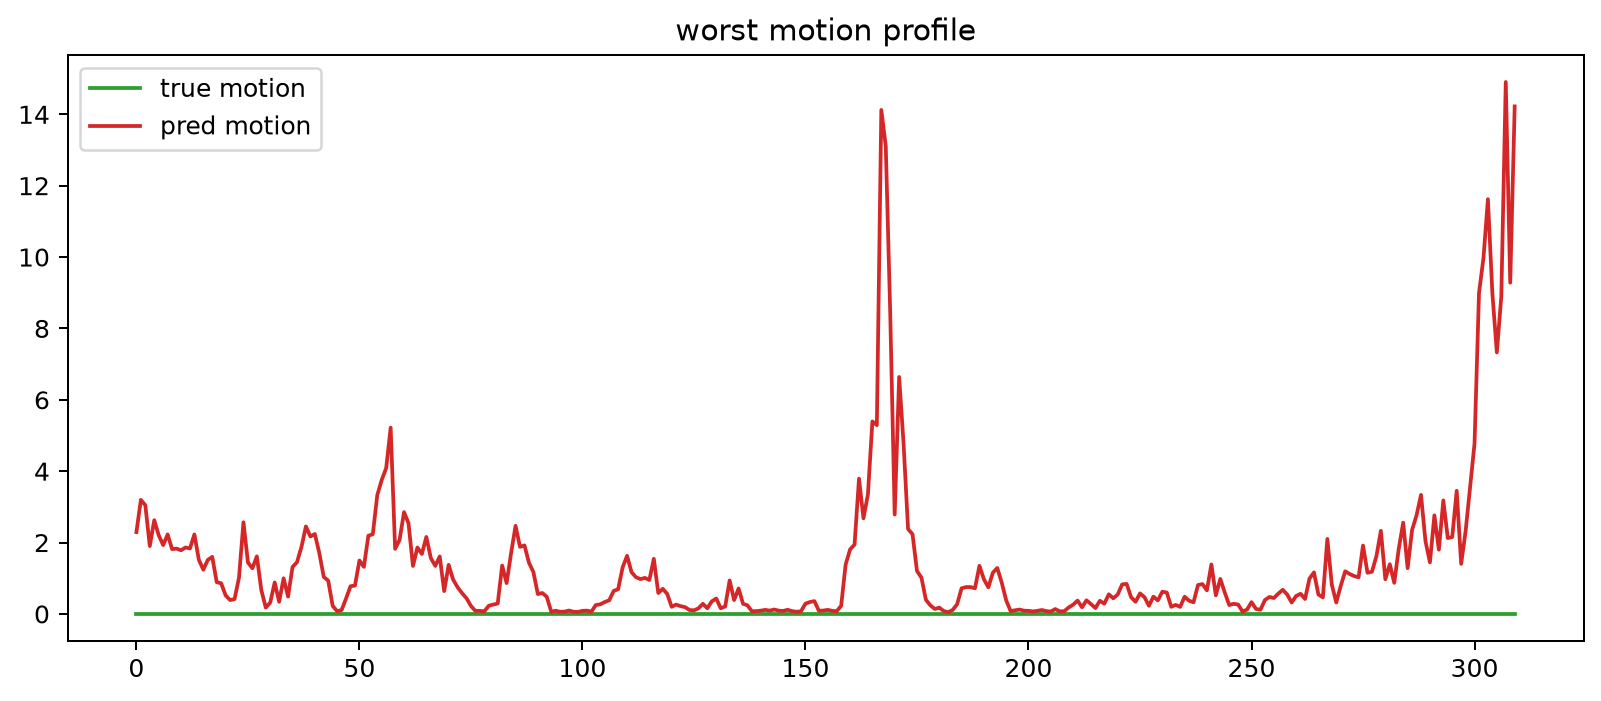

worst_residue_error.png


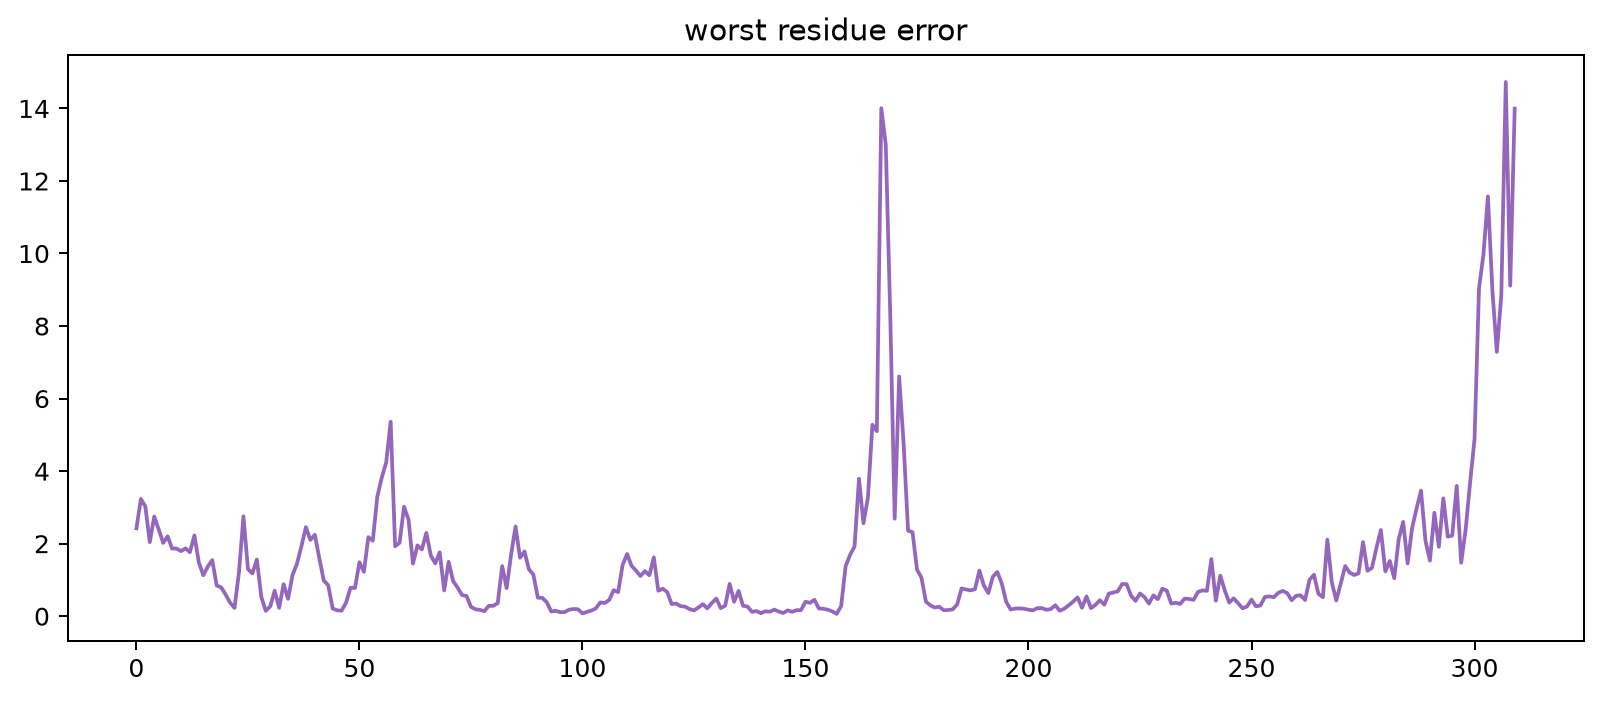

In [107]:
plots = sorted(FIGURE_ROOT.glob('*_training_curves.png'))
for path in plots[:6]:
    print(path.name)
    display(Image(filename=str(path)))

example_dir = FIGURE_ROOT / 'examples'
if example_dir.is_dir():
    for label in ['best', 'median', 'worst']:
        overlay = example_dir / f'{label}_overlay.png'
        motion = example_dir / f'{label}_motion_overlay.png'
        residue_error = example_dir / f'{label}_residue_error.png'
        for path in [overlay, motion, residue_error]:
            if path.is_file():
                print(path.name)
                display(Image(filename=str(path)))


In [108]:
if PIPELINE_READY and not comparison_table.empty:
    def _row(frame: pd.DataFrame, method: str) -> pd.Series:
        return frame.loc[frame['Method'] == method].iloc[0]

    identity = _row(comparison_table, 'Identity')
    best_row = comparison_table.sort_values('RMSD Pred→Target').iloc[0]
    egnn_baseline_name = 'EGNN_no_prior' if 'EGNN_no_prior' in comparison_table['Method'].values else None
    guided_name = 'MobilityGuidedEGNN' if 'MobilityGuidedEGNN' in comparison_table['Method'].values else None

    lines = []
    lines.append(f"Identity RMSD pred→target: {identity['RMSD Pred→Target']:.3f} Å")
    if egnn_baseline_name:
        egnn = _row(comparison_table, egnn_baseline_name)
        lines.append(f"EGNN baseline RMSD pred→target: {egnn['RMSD Pred→Target']:.3f} Å")
    if guided_name:
        guided = _row(comparison_table, guided_name)
        lines.append(f"Mobility-guided EGNN RMSD pred→target: {guided['RMSD Pred→Target']:.3f} Å")
    lines.append(f"Best method: {best_row['Method']} ({best_row['RMSD Pred→Target']:.3f} Å)")
    lines.append(f"XGBoost classifier validation ROC-AUC: {mobility_prior_summary['classifier_metrics']['validation']['roc_auc']:.3f}")
    lines.append(f"XGBoost classifier test ROC-AUC: {mobility_prior_summary['classifier_metrics']['test']['roc_auc']:.3f}")
    print('\n'.join(lines))

    if guided_name:
        guided = _row(comparison_table, guided_name)
        delta_vs_identity = float(guided['RMSD Pred→Target'] - identity['RMSD Pred→Target'])
        print(f'Guided vs identity delta RMSD: {delta_vs_identity:+.3f} Å')
        if guided['Success Rate'] > identity['Success Rate']:
            print('Conclusion: mobility prior improves success rate over identity.')
        else:
            print('Conclusion: mobility prior does not beat identity on this fold.')
else:
    print('No mobility-guided results are available to summarize.')


Identity RMSD pred→target: 3.316 Å
EGNN baseline RMSD pred→target: 3.590 Å
Mobility-guided EGNN RMSD pred→target: 3.741 Å
Best method: Identity (3.316 Å)
XGBoost classifier validation ROC-AUC: 0.748
XGBoost classifier test ROC-AUC: 0.852
Guided vs identity delta RMSD: +0.425 Å
Conclusion: mobility prior improves success rate over identity.
